# 25_03 Z-score 기반 이상치 탐색

In [1]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


## 실습 1. 손으로 Z-score 계산·판정
### 목표
정상 다섯 값으로 평균·표준편차를 구해 새 값의 Z-score를 손으로 계산·판정
### 단계
- 정상 다섯 값의 평균과 표준편차를 구하기
- 새 값마다 평균을 빼고 표준편차로 나눠 Z를 구하기
- 절댓값이 기준을 넘으면 이상으로 판정
### 예상 결과
53은 약 1.9, 68은 약 11.4, 40은 약 -6.3


In [26]:
# 실습1 코드
vals = np.array([48, 50, 52, 49, 51])
m = vals.mean()
s = vals.std(ddof=1) # ddof = 0 기본 / 1로 만들면 표본표준편차 기준으로 편향 보정

print(f"평균 : {m} \n 표준편차 : {round(s, 4)}")

for v in [53, 68, 40]:
    print(v, "-> Z =", round((v -m) / s, 1))

평균 : 50.0 
 표준편차 : 1.5811
53 -> Z = 1.9
68 -> Z = 11.4
40 -> Z = -6.3


## 실습 2. 정상 데이터 기준 통계량 계산
### 목표
데이터를 불러와 구조를 확인하고 정상만 골라 이상 판정 기준 통계량을 계산
### 단계
- 파일을 불러와 크기와 정답 분포 확인
- 정답이 정상인 행만 골라내기
- 정상의 평균과 표준편차를 이상 판정 기준으로 삼기
### 예상 결과
정상 96·이상 8, 정상 평균 0.1015·표준편차 0.0184

In [37]:
# 실습2 코드
MI = "../csv/25_mimii_features.csv"

df = pd.read_csv(MI)
print(f"shape : {df.shape} \n 라벨 : {df["label"].value_counts().to_dict()}")

normal = df[df["label"] == 0]
rms_mean = normal["rms"].mean()
rms_std = normal["rms"].std()
print(f"정상 평균 : {round(rms_mean, 4)} \n 표준편차 : {round(rms_std, 4)}")

shape : (104, 4) 
 라벨 : {0: 96, 1: 8}
정상 평균 : 0.1015 
 표준편차 : 0.0184


## 실습 3. Z-score 컬럼 만들기
### 목표
모든 행의 rms를 Z-score로 바꿔 새 열로 담기
### 단계
- 각 값에서 정상 평균을 빼고 정상 표준편차로 나누기
- 절댓값을 취해 방향과 무관하게 벗어난 정도로 만들기
- Z가 큰 상위 몇 개를 확인
### 예상 결과
Z 상위 세 값이 28.1·23.3·22.5로 매우 큼


In [38]:
# 실습3 코드
# z-score 계산
# 정제 / 전처리를 통해 이상치를 없애는 처리작업이 필요
df["z_rms"] = np.abs((df["rms"] - rms_mean) / rms_std)
df.head()

print(f"z 상위 : {df["z_rms"].round(1).nlargest(3).tolist()}")

z 상위 : [28.1, 23.3, 22.5]


## 실습 4. 임계값 기준 이상치 필터링
### 목표
기준값을 넘는 Z-score를 이상치로 걸러내기
### 단계
- 이상 판정 기준을 3으로 정하기
- Z가 기준을 넘는 행만 골라내기
- 걸러진 이상치 개수를 확인
### 예상 결과
기준 3에서 이상치 8건

In [ ]:
# 실습4 코드
threshold = 3.0
anomalies = df[df["z_rms"] > threshold]

print("이상치 개수", len(anomalies))
anomalies.head()    #헤드 표 표시

이상치 개수 8


,rms,spectral_centroid,zero_crossing_rate,label,z_rms
0,0.6196,2906.2,0.2283,1,28.147276
10,0.3925,2675.1,0.1978,1,15.809984
16,0.4950,2845.9,0.2089,1,21.378335
19,0.5158,2953.3,0.2280,1,22.508303
37,0.5098,2806.8,0.2248,1,22.182350


## 실습 5. 이상치 산점도 시각화
### 목표
순서대로 Z를 점으로 찍고 기준선을 그어 이상치를 눈으로 확인
### 단계
- 각 행 순서를 가로축, Z를 세로축으로 산점도 그리기
- 기준값 위치에 가로 점선 긋기
- 점선 위로 솟은 점을 이상치로 확인
### 예상 결과
대부분 낮게 깔리고 몇몇 점이 기준선 위로 크게 솟음


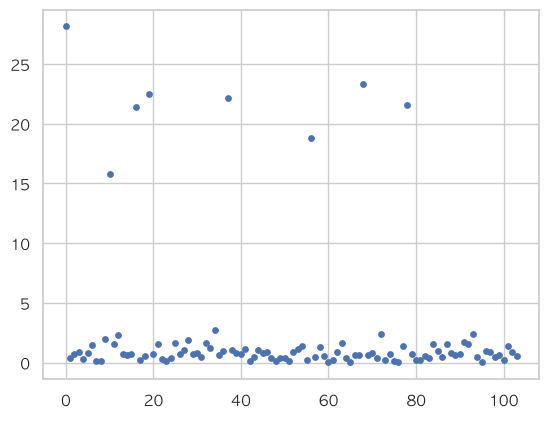

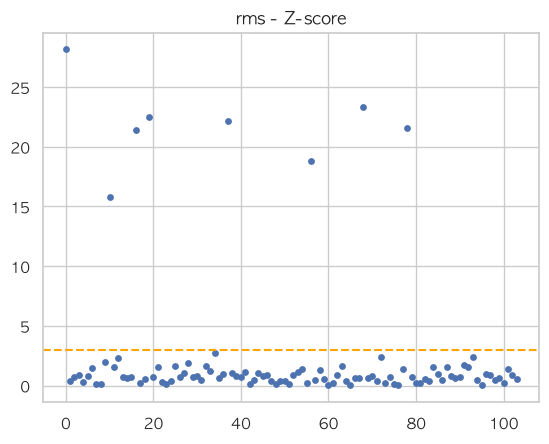

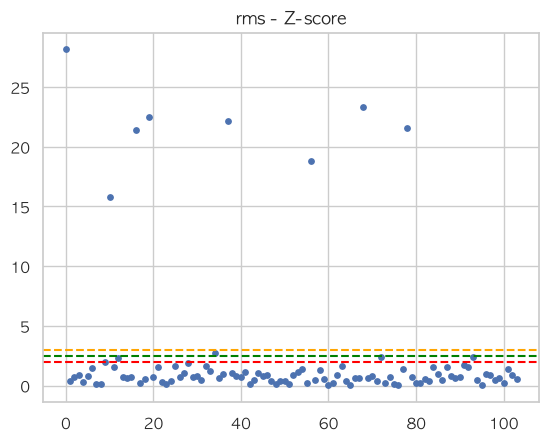

In [40]:
# 실습5 코드

plt.scatter(range(len(df)), df["z_rms"], s = 15)
plt.show()

plt.scatter(range(len(df)), df["z_rms"], s = 15)
plt.axhline(y = threshold, color = "orange", linestyle = "--")
plt.title("rms - Z-score")
plt.show()

# Z-score을 통해 이상 값들을 일정 기준을 통해 보기 쉽게 하기 위해

plt.scatter(range(len(df)), df["z_rms"], s = 15)
plt.axhline(y = threshold, color = "orange", linestyle = "--")
plt.axhline(y = 2.5, color = "green", linestyle = "--")
plt.axhline(y = 2.0, color = "red", linestyle = "--")
plt.title("rms - Z-score")
plt.show()

## 실습 6. 다른 feature에도 Z-score 적용
### 목표
같은 방식을 다른 특징에도 적용해 이상치 개수를 비교
### 단계
- 다른 특징마다 정상 평균·표준편차로 Z를 계산
- 기준을 넘는 개수를 세기
- 특징별 탐지 개수를 비교
### 예상 결과
두 특징 모두 기준 3에서 이상치 8건

In [41]:
# 실습6 코드
cols = {"spectral_centroid", "zero_crossing_rate"}

for col in cols:
    col_mean = normal[col].mean()
    col_std = normal[col].std()
    # z = np.abs() # 절대값
    z = np.abs((df[col] - col_mean) / col_std)
    print(col, z) 
    print(col, "이상치 : ", int((z > threshold).sum()))
    # 애매하게 걸쳐 있는 것들이 보이지 않음. 
    # 동 떨어진 곳에 있는 레이블들이 어디에 존재하는지 볼 수 있는 코드를 설계

spectral_centroid 0      10.327815
1       0.887915
2       2.613969
3       0.487990
4       0.133660
         ...    
99      0.096846
100     1.503122
101     1.817877
102     1.260153
103     0.495851
Name: spectral_centroid, Length: 104, dtype: float64
spectral_centroid 이상치 :  8
zero_crossing_rate 0      15.582296
1       0.665064
2       1.487173
3       0.077087
4       1.481430
         ...    
99      1.693473
100     0.829839
101     1.386011
102     0.405753
103     0.092548
Name: zero_crossing_rate, Length: 104, dtype: float64
zero_crossing_rate 이상치 :  8


## 실습 7. Z-score 결과와 실제 label 비교
### 목표
Z-score 판정 결과를 실제 정답과 대조해 정탐·미탐·오탐을 세기
### 단계
- Z가 기준을 넘으면 이상으로 예측한 열 만들기
- 예측과 실제 정답을 짝지어 정탐·미탐·오탐 세기
- 셋의 균형으로 탐지 품질 확인
### 예상 결과
정탐 8·미탐 0·오탐 0으로 완벽 분리

In [47]:
# 실습7 코드

df["pred"] = (df["z_rms"] > threshold).astype(int)
df.head()

tp = ((df["pred"] == 1) & (df["label"] == 1)).sum() # label과 pred가 모두 1인 경우의 수
fn = ((df["pred"] == 0) & (df["label"] == 1)).sum() # label과 pred가 모두 0인 경우의 수
fp = ((df["pred"] == 1) & (df["label"] == 0)).sum() # label과 pred가 모두 1인 경우의 수
print(f"정탐 {int(tp)} 미탐 {int(fn)} 오탐 {int(fp)}")

정탐 8 미탐 0 오탐 0


## 실습 8. 임계값 바꿔 결과 비교
### 목표
기준값을 바꿔 가며 탐지 개수가 어떻게 변하는지 비교
### 단계
- 여러 기준값을 준비
- 각 기준마다 넘는 개수를 세기
- 기준이 낮을수록 많이 잡힘을 확인
### 예상 결과
기준 2는 13건, 2.5는 9건, 3은 8건


In [48]:
# 실습8 코드
for t in [2.0, 2.5, 3.0]: # 소수 추천, 리스트 안에는 최대한 같은 타입
    print(f"임계값 t = {t} -> 이상치 {int((df["z_rms"] > t).sum())} 개")

임계값 t = 2.0 -> 이상치 13 개
임계값 t = 2.5 -> 이상치 9 개
임계값 t = 3.0 -> 이상치 8 개


## 실습 9. C-MAPSS 샘플로 Z-score 적용
### 목표
같은 Z-score 방법을 설비 센서 데이터에 적용
### 단계
- 초반 정상 구간을 기준으로 평균·표준편차 잡기
- 전체 회차의 센서 값을 Z로 변환
- Z가 큰 후반 상위 값을 확인
### 예상 결과
후반 Z 상위 세 값이 15.6·11.6·11.6으로 크게 벗어남


In [50]:
# 실습9 코드

CM = "../csv/25_cmapss_sample.csv"

cm = pd.read_csv(CM)
# cm.head()
# cm.shape # (40, 5)

# 전체 40개 row 중 초반 20개만 추리기
ref = cm[cm["cycle"] <= 20]
# ref.shape  # (20, 5)

# 추려진 20개의 평균, 표준편차 구하기
mean_c = ref["sensor_2"].mean()
std_c = ref["sensor_2"].std()

# 평균과 표준편차를 이용해서 Z-score 를 구하여 Z 컬럼 생성하기
cm["Z-score"] = np.abs((cm["sensor_2"] - mean_c) / std_c)
# cm.head()

print(f"후반 Z 상위 : {cm["Z-score"].round(1).nlargest(3).tolist()}")
# 후반 Z 상위 : [15.6, 11.6, 11.6]

후반 Z 상위 : [15.6, 11.6, 11.6]


## 실습 10. 종합 이상 구간 정비 리포트
### 목표
탐지 결과를 정비 리포트로 정리해 우선 점검 대상을 뽑기
### 단계
- 이상치 비율을 계산
- 점검 대상·기준·탐지 건수를 리포트로 출력
- Z 상위 몇 건을 최우선 점검으로 정리
### 예상 결과
이상 8건(약 7.7퍼센트), Z 상위 3건이 최우선 점검


In [52]:
# 실습10 코드

# anomalies = df[df["z_rms"] > threshold]

ratio = (len(anomalies) / len(df)) * 100
print(round(ratio, 4))

탐지건수 = len(anomalies)
탐지율 = round(ratio, 1)

print(" === 이상 구간 정비 리포트 === ")
print(f" 점검 대상 : MIMII rms \n 기준 : |Z-core| > {threshold} \n 탐지 : {탐지건수} 건( {탐지율} %)")
print(anomalies.nlargest(3, "z_rms")[["rms", "z_rms"]].to_string(index = False))

7.6923
 === 이상 구간 정비 리포트 === 
 점검 대상 : MIMII rms 
 기준 : |Z-core| > 3.0 
 탐지 : 8 건( 7.7 %)
   rms     z_rms
0.6196 28.147276
0.5301 23.285155
0.5158 22.508303
